In [1]:
import numpy as np
import os
import temet
import h5py

In [2]:
def load_spectra_from_boxes(gp_paths, spectrumNums, y_param="flux", z=2.0):
    """ Loads all spectra specified in spectrumNums for all boxes specified in gp_paths

    Args:
        gp_paths (list): List of Gridpoint folder paths to load spectra from.
        spectrumNums (list): List of indices for the spectra.
        y_param (str, optional): name of field to return data from. Defaults to 'flux'.
        z (float, optional): Redshift value. Defaults to 2.0.

    Returns:
        wavelengths (list): one np.array containing the wavelengths of the spectra for each box
        y_param (list): len(spectrumNums) number of np.arrays for each box (each is one spectrum)
        params (list): [Omega0, OmegaBaryon, OmegaLambda, HubbleParam] for each box
    """
    
    wavelengths = []
    y_out = []
    #params = []
    
    for gp_path in gp_paths:
        gp_name = gp_path.split("/")[-2]
        path = gp_path + f"data.files/spectra/spectra_{gp_name}_z{z:.1f}_n100d2-fullbox_SDSS-BOSS_HI_combined.hdf5"
        #print(path)
        with h5py.File(path, "r") as f:     
            # Zugriff auf einzelne Datasets
            #print(f.keys())  # Gibt die Namen der Datasets im HDF5-File aus
            wavelengths.append(f["wave"][:])  # Das [:] liest das gesamte Dataset in ein NumPy-Array ein
            y_out.append(f[y_param][:][spectrumNums])

        #Omega0, OmegaBaryon, OmegaLambda, HubbleParam = get_cosmo_parameters(gp_path)

        #params.append([Omega0, OmegaBaryon, OmegaLambda, HubbleParam])

    return wavelengths, y_out#, params

In [3]:
import glob

def redshift_wavelength_forward(z, wavelength):
    """ Redshifts a wavelength forward (wavelength gets bigger with more redshift)
    
    Args:
        z (float): redshift to apply to wavelength
        wavelength (float or np.array): wavelength to be shifted

    Returns:
        (float or np.array): redshifted wavelength
    """
    return (z+1)*wavelength

def get_data_from_header(output_dir, snapN, param='BoxSize'):
    """ get data from the header of a specified simulation and snapshot
    
    Args:
        output_dir (string): base directory of the simulation
        snapN (int): number of the snapshot
        param (string): parameter of the hdf5 file (the parameter to read)

    Returns:
        np.array : Array containing the specific data
    """

    snapdir = glob.glob(output_dir+f"output/snapdir_*{snapN}")[0]
    snap_files = os.listdir(snapdir)
    file_name = snap_files[0]
    file_path = snapdir+f"/{file_name}"

    with h5py.File(file_path, "r") as f:
        header = f['Header']
        return_param = header.attrs[param]
        
    return return_param

def get_edges(gp_path, snapN=12, redshift=2.0):
    Ly_alpha_0 = 1215.67 

    sim = temet.sim(gp_path, redshift=redshift)
    dz = sim.dz
    z = get_data_from_header(gp_path, snapN, param="Redshift")
    z = z + dz
    print(dz)
    right_edge = redshift_wavelength_forward(z, Ly_alpha_0)
    left_edge = redshift_wavelength_forward(z - dz, Ly_alpha_0)  # well this is awkward and ugly code (this really is just z + dz - dz)

    return left_edge, right_edge

In [4]:
sim_suite_location = "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/test_L50n512/"
gps_to_reorder = []
gps_to_reorder.append(sim_suite_location)

In [5]:
redshifts = [2.0, 2.2, 2.4, 2.6, 2.8, 3.0]
snaps = [12, 10, 8, 6, 4, "002"]
fluxes_plot = []

for i, z in enumerate(redshifts):
    w, y = load_spectra_from_boxes(gps_to_reorder, spectrumNums=[i for i in range(10000)], z=z)
    fluxes = np.array(y[0])
    l, r = get_edges(gps_to_reorder[0], snapN=snaps[i], redshift=z)
    fluxes = fluxes[:, (w[0] >= l) & (w[0] <= r)]
    fluxes_plot.append(fluxes)

0.05070930329234136
0.05562459149124965
0.06045263026083081
0.06575164907557607
0.07080841194850462
0.07628770595019585


findfont: Failed to find font weight medium, now using 300.
findfont: Failed to find font weight medium, now using 300.
findfont: Failed to find font weight normal, now using 300.


/tmp/ipykernel_2835475/3105365859.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


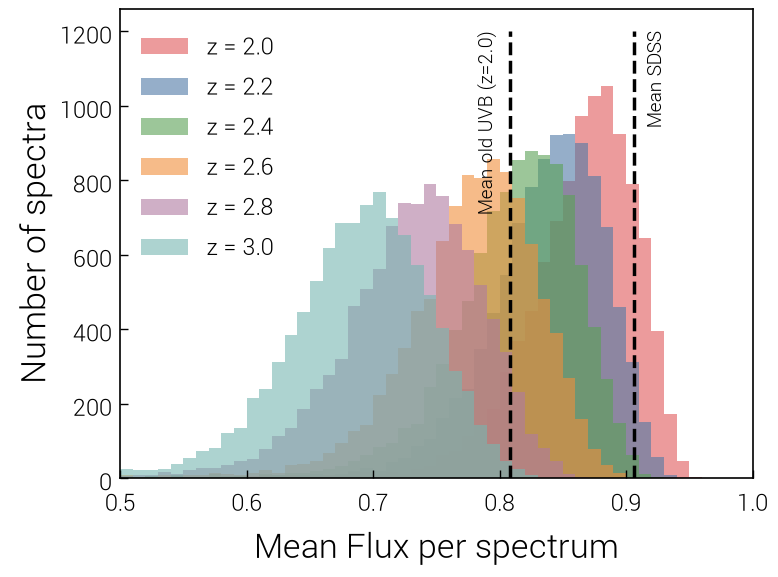

In [6]:
import matplotlib.pyplot as plt

range_flux = (0.5, 1.0)

plot_list = []

for i in range(len(redshifts)):
    h, edges = np.histogram(fluxes_plot[i].mean(axis=1), bins=50, range=range_flux)

    plot_list.append((h, edges))

fig = plt.subplots(figsize=(8, 6))

for i, (h, edges) in enumerate(plot_list):
    plt.stairs(h, edges, fill=True, alpha=0.6, label=f"z = {redshifts[i]:.1f}")

x_right = 0.9065568
x_left = 0.8079474703208721
y_top = 1200
plt.vlines(x_right, ymin=0, ymax=y_top, color="black", linestyle="--")
plt.text(x_right + 0.005, y_top, "Mean SDSS", verticalalignment="top", rotation=90)
plt.vlines(x_left, ymin=0, ymax=y_top, color="black", linestyle="--")
plt.text(x_left - 0.03, y_top, "Mean old UVB (z=2.0)", verticalalignment="top", rotation=90)


plt.xlim(range_flux)
plt.xlabel("Mean Flux per spectrum")
plt.ylabel("Number of spectra")
plt.legend()
plt.tight_layout()

plt.savefig("plots/mean_flux_distribution_refbox.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [7]:
def load_spectra_from_boxes(gp_paths, spectrumNums, z=2.0, y_param="flux"):
    """ Loads all spectra specified in spectrumNums for all boxes specified in gp_paths

    Args:
        gp_paths (list): List of Gridpoint folder paths to load spectra from.
        spectrumNums (list): List of indices for the spectra.
        y_param (str, optional): name of field to return data from. Defaults to 'flux'.

    Returns:
        wavelengths (list): one np.array containing the wavelengths of the spectra for each box
        y_param (list): len(spectrumNums) number of np.arrays for each box (each is one spectrum)
        params (list): [Omega0, OmegaBaryon, OmegaLambda, HubbleParam] for each box
    """
    
    wavelengths = []
    y_out = []
    
    for gp_path in gp_paths:
        gp_name = gp_path.split("/")[-2]
        path = gp_path + f"data.files/spectra/spectra_{gp_name}_z{z:.1f}_n100d2-fullbox_SDSS-BOSS_HI_combined.hdf5"

        with h5py.File(path, "r") as f:     
            # Zugriff auf einzelne Datasets
            wavelengths.append(f["wave"][:])  # Das [:] liest das gesamte Dataset in ein NumPy-Array ein
            y_out.append(f[y_param][:][spectrumNums])

    return wavelengths, y_out

0.05070930329234136
0.05562459149124965
0.06045263026083081
0.06575164907557607
0.07080841194850462


findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight med

0.07628770595019585


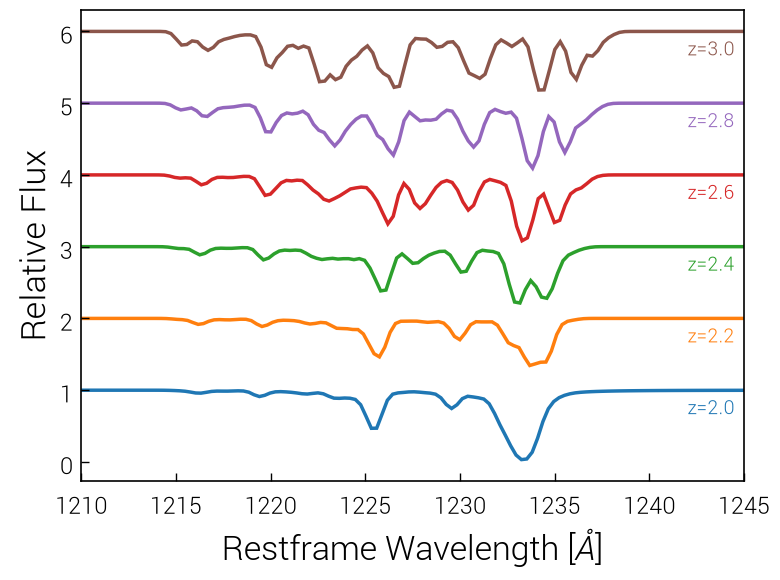

In [8]:
import matplotlib.colors as mcolors

fig = plt.subplots(figsize=(8, 6))

ray_num = 2

x_max = 1245

colors = []
for name, color in mcolors.TABLEAU_COLORS.items():
    colors.append(color)

for i in range(len(redshifts)):
    z = redshifts[i]
    w, y = load_spectra_from_boxes(gps_to_reorder, [ray_num], z=z)
    l, r = get_edges(gps_to_reorder[0], snapN=snaps[i], redshift=z)

    l, r = l/(z+1), r/(z+1)
    x_plot = np.array(w[0])/(z+1) - l + 1215.67
    y_plot = y[0][0] + i

    #plt.vlines(l - l + 1215.67, ymin=i, ymax=i+1, color="black", linestyle="--", alpha=0.5)
    #plt.vlines(r - l + 1215.67, ymin=i, ymax=i+1, color="black", linestyle="--", alpha=0.5)

    plt.text(x_max-0.5, i+0.95, f"z={z:.1f}", verticalalignment="top", horizontalalignment="right", color=colors[i])

    plt.plot(x_plot, y_plot, c=colors[i])

plt.xlim(1210, 1245)
plt.xlabel(r"Restframe Wavelength [$\AA$]")
plt.ylabel("Relative Flux")
plt.savefig("plots/spectra_stack_one_los_restwavelength.pdf", format="pdf")
plt.show()

0.05070930329234136
0.053101283204621375
0.05562459149124965
0.057981922116438156
0.06045263026083081
0.06304040669210353


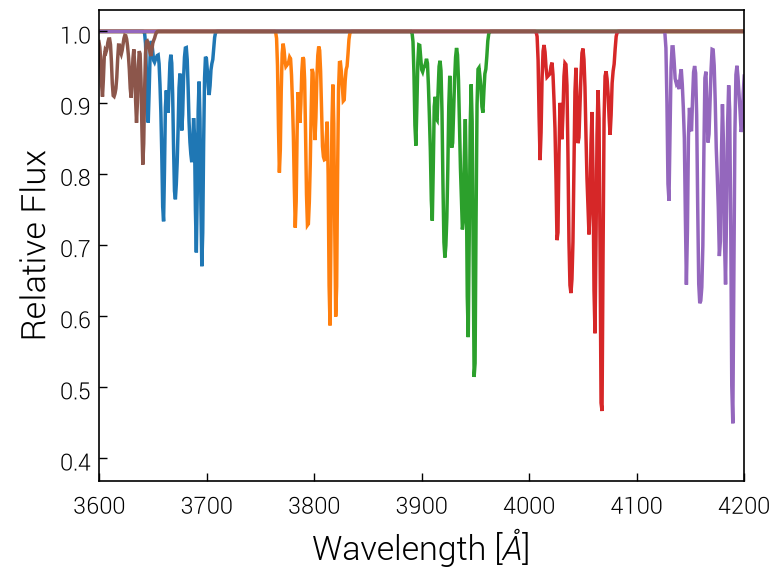

In [9]:
import matplotlib.colors as mcolors

fig = plt.subplots(figsize=(8, 6))

ray_num = 5555
redshifts = [2.0, 2.1, 2.2, 2.3, 2.4, 2.5]#, 2.5, 2.6, 2.7, 2.8]
snaps = [12, 11, 10, 9, 8, 7]#, 7, 6, 5, 4]

x_max = 1245
ly_alpha_rest = 1215.67

colors = []
for name, color in mcolors.TABLEAU_COLORS.items():
    colors.append(color)

for i in range(len(redshifts)):
    z = redshifts[i]
    w, y = load_spectra_from_boxes(gps_to_reorder, [ray_num], z=z)
    l, r = get_edges(gps_to_reorder[0], snapN=snaps[i], redshift=z)

    # l, r = l/(z+1), r/(z+1)
    x_plot = np.array(w[0])#/(z+1) - l + 1215.67
    y_plot = y[0][0]#  + i

    #plt.vlines(l - l + 1215.67, ymin=i, ymax=i+1, color="black", linestyle="--", alpha=0.5)
    #plt.vlines(r - l + 1215.67, ymin=i, ymax=i+1, color="black", linestyle="--", alpha=0.5)

    # plt.text(x_max-0.5, i+0.95, f"z={z:.1f}", verticalalignment="top", horizontalalignment="right", color=colors[i])

    plt.plot(x_plot, y_plot, c=colors[i])

plt.xlim(3600, 4200)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel("Relative Flux")
plt.savefig("plots/spectra_stack_one_los_truewavelength.pdf", format="pdf")
plt.show()

In [10]:
sim_suite_location = "/pfs/10/project/bw21g005/ly_alpha_sbi_paper/test_L50n512/"
gps_to_reorder = []
gps_to_reorder.append(sim_suite_location)


redshifts = [2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 3.0]
snaps = [12, 11, 10, 9, 8, 7, 6, 5, 4, "002"]
fluxes_plot = []
mean_fluxes = []
std_fluxes = []

for i, z in enumerate(redshifts):
    print(z)
    w, y = load_spectra_from_boxes(gps_to_reorder, spectrumNums=[i for i in range(10000)], z=z)
    fluxes = np.array(y[0])
    l, r = get_edges(gps_to_reorder[0], snapN=snaps[i], redshift=z)
    fluxes = fluxes[:, (w[0] >= l) & (w[0] <= r)]

    fluxes_plot.append(fluxes)

    mean_flux = fluxes.mean(axis=1).mean()
    std_flux = fluxes.mean(axis=1).std()

    mean_fluxes.append(mean_flux)
    std_fluxes.append(std_flux)

    print("mean", mean_flux)
    print("std", std_flux)

2.0


0.05070930329234136
mean 0.862216
std 0.05306012
2.1
0.053101283204621375
mean 0.84775263
std 0.05732265
2.2
0.05562459149124965
mean 0.8334696
std 0.062073834
2.3
0.057981922116438156
mean 0.81848663
std 0.06478215
2.4
0.06045263026083081
mean 0.80872756
std 0.06288788
2.5
0.06304040669210353
mean 0.7878713
std 0.0626153
2.6
0.06575164907557607
mean 0.77545476
std 0.06401765
2.7
0.06822927706486137
mean 0.7567047
std 0.0641812
2.8
0.07080841194850462
mean 0.7270479
std 0.06509538
3.0
0.07628770595019585
mean 0.6847418
std 0.06587407


In [11]:
# Data from https://arxiv.org/abs/0709.2382v3 

kirkman_metal_corr = [
    0.125, 0.109, 0.154, 0.213, 0.170, 0.228,
    0.262, 0.281, 0.335, 0.346, 0.413, 0.424,
    0.428, 0.453, 0.576, 0.738, 0.731, 0.795,
    0.844, 0.908, 0.906, 1.095, 1.058
]

sigma_tau_eff_tot = [
    0.027, 0.022, 0.023, 0.026, 0.018, 0.022,
    0.024, 0.026, 0.030, 0.029, 0.035, 0.036,
    0.036, 0.038, 0.043, 0.051, 0.065, 0.062,
    0.057, 0.056, 0.082, 0.110, 0.132
]

z_paper = [
    2.0, 2.1, 2.2, 2.3, 2.4, 2.5,
    2.6, 2.7, 2.8, 2.9, 3.0, 3.1,
    3.2, 3.3, 3.4, 3.5, 3.6, 3.7,
    3.8, 3.9, 4.0, 4.1, 4.2]


tau = np.array(kirkman_metal_corr)

# Flux
F = np.exp(-tau)

# Exact asymmetric error propagation
F_low = np.exp(-(tau + sigma_tau_eff_tot))
F_high = np.exp(-(tau - sigma_tau_eff_tot))

# Error-bar sizes
dF_minus = F - F_low
dF_plus = F_high - F


In [23]:
sdss_mean_fluxes = [0.95869124, 0.9078099, 0.87776124]
sdss_errs = [0.13130197, 0.11410483, 0.124599144]
sdss_zs = [2.0, 2.1, 2.2]

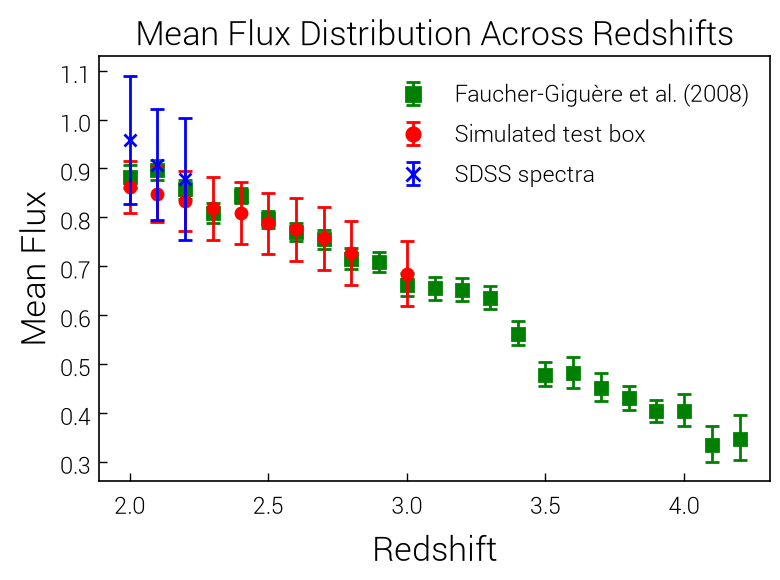

In [28]:
import matplotlib.pyplot as plt

fig = plt.subplots(figsize=(8, 6))

plt.errorbar(
    z_paper, F,
    yerr=[dF_minus, dF_plus],
    fmt='s',
    capsize=5,
    label="Faucher-Giguère et al. (2008)",
    color='green',
    barsabove=True,
    elinewidth=2,
    markeredgewidth=2,
    zorder=1,
)

plt.errorbar(
    redshifts, mean_fluxes,
    yerr=std_fluxes,
    fmt='o',
    capsize=5,
    label="Simulated test box",
    color='red',
    barsabove=True,
    elinewidth=2,
    markeredgewidth=2,
    zorder=3
)

plt.errorbar(
    sdss_zs, sdss_mean_fluxes,
    yerr=sdss_errs,
    fmt='x',
    capsize=5,
    label="SDSS spectra",
    color='blue',
    barsabove=True,
    elinewidth=2,
    markeredgewidth=2,
    zorder=5
)

plt.xlabel("Redshift")
plt.ylabel("Mean Flux")
plt.title("Mean Flux Distribution Across Redshifts")
plt.legend()

plt.savefig("plots/z_vs_mean_flux.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
0.862216/0.6847418

1.2591841187437367